Deep Learning Lab Assignment

Name: Ritesh Kumar  
Roll No: 24cd3035    

* Framework Used: PyTorch

# Task - 1

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [9]:
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)
print("Matplotlib Version:", plt.matplotlib.__version__)
print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

NumPy Version: 2.3.5
Pandas Version: 2.3.3
Matplotlib Version: 3.10.6
PyTorch Version: 2.11.0
Torchvision Version: 0.26.0


In [10]:
print("MPS Available (Mac GPU):", torch.backends.mps.is_available())

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS GPU")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU ")
else:
    device = torch.device("cpu")
    print("Running on CPU")

print("Selected Device:", device)

# This system uses Apple M2 chip, which does not support CUDA.
# PyTorch uses MPS (Metal Performance Shaders) for GPU acceleration.
# GPU (MPS/CUDA) is faster than CPU because it performs parallel computations.
# On GPU, training can be significantly faster and allows larger batch sizes.

MPS Available (Mac GPU): True
Using Apple MPS GPU
Selected Device: mps


In [11]:
# Reproducibility

torch.manual_seed(42) # torch.manual_seed → controls model weights and operations
np.random.seed(42) # numpy seed → controls NumPy randomness
random.seed(42) # random.seed → controls Python randomness

if torch.backends.mps.is_available():
    torch.mps.manual_seed(42)

In [12]:
from torchvision.datasets import MNIST, CIFAR10

mnist_train = MNIST(root="./data", train=True, download=True)
mnist_test = MNIST(root="./data", train=False, download=True)

cifar_train = CIFAR10(root="./data", train=True, download=True)
cifar_test = CIFAR10(root="./data", train=False, download=True)

In [13]:
import numpy as np

# MNIST
x_train_m = mnist_train.data.numpy()
y_train_m = mnist_train.targets.numpy()

x_test_m = mnist_test.data.numpy()
y_test_m = mnist_test.targets.numpy()

# CIFAR-10
x_train_c = np.array(cifar_train.data)
y_train_c = np.array(cifar_train.targets)

x_test_c = np.array(cifar_test.data)
y_test_c = np.array(cifar_test.targets)

In [14]:
print("MNIST Train Shape:", x_train_m.shape)
print("MNIST Test Shape:", x_test_m.shape)

print("CIFAR Train Shape:", x_train_c.shape)
print("CIFAR Test Shape:", x_test_c.shape)

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)


In [15]:
print("\nMNIST dtype:", x_train_m.dtype)
print("CIFAR dtype:", x_train_c.dtype)


MNIST dtype: uint8
CIFAR dtype: uint8


In [16]:
print("\nMNIST range:", x_train_m.min(), x_train_m.max())
print("CIFAR range:", x_train_c.min(), x_train_c.max())


MNIST range: 0 255
CIFAR range: 0 255


In [17]:
unique, counts = np.unique(y_train_m, return_counts=True)
print("MNIST Class Distribution:")
print(dict(zip(unique, counts)))  
#MNIST class distribution is approximately balanced
# each class has around 6000 samples

MNIST Class Distribution:
{np.int64(0): np.int64(5923), np.int64(1): np.int64(6742), np.int64(2): np.int64(5958), np.int64(3): np.int64(6131), np.int64(4): np.int64(5842), np.int64(5): np.int64(5421), np.int64(6): np.int64(5918), np.int64(7): np.int64(6265), np.int64(8): np.int64(5851), np.int64(9): np.int64(5949)}


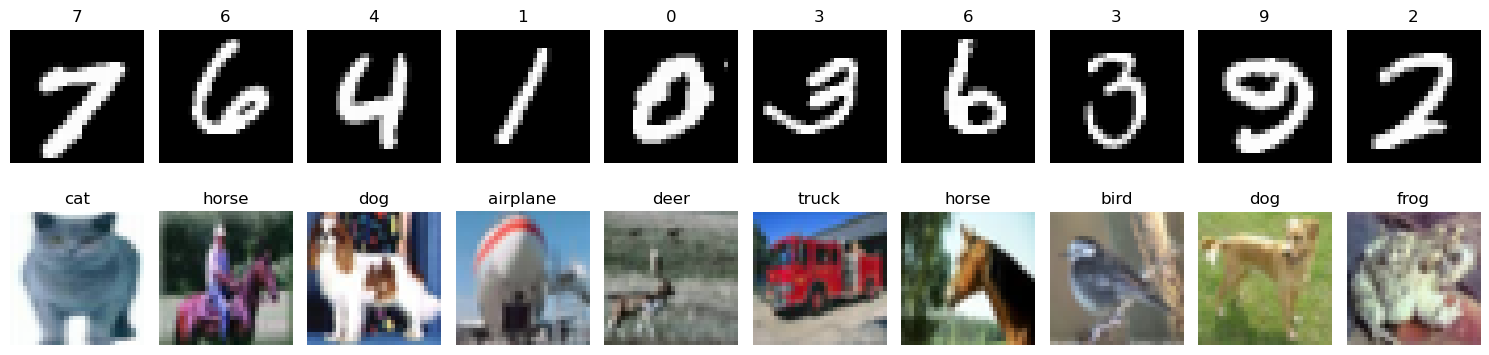

In [19]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# MNIST row
for i in range(10):
    idx = np.random.randint(len(x_train_m))
    axes[0, i].imshow(x_train_m[idx], cmap='gray')
    axes[0, i].set_title(str(y_train_m[idx]))
    axes[0, i].axis('off')

# CIFAR row
classes = cifar_train.classes
for i in range(10):
    idx = np.random.randint(len(x_train_c))
    axes[1, i].imshow(x_train_c[idx])
    axes[1, i].set_title(classes[y_train_c[idx]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [20]:
def preprocessfunc(x, y, is_mnist=False):

    print("BEFORE PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    
    # Normalize to [0, 1]
    x = x.astype(np.float32) / 255.0  # Pixel values are scaled to the range [0,1] by dividing by 255.0.
     # This helps in faster convergence and stable training of neural networks.
    
    # Reshape MNIST (add channel dimension)
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
    
    # One-hot encode labels(Labels are converted into vectors of length 10, where the correct class index is 1 and others are 0.)
    y_onehot = np.eye(10)[y]
    
    print("\nAFTER PREPROCESSING")
    print("Shape:", x.shape)
    print("Dtype:", x.dtype)
    print("Min/Max:", x.min(), x.max())
    print("Sample values:", x.flatten()[:10])
    print("Label sample (one-hot):", y_onehot[0])
    
    return x, y_onehot

In [21]:
x_train_m_p, y_train_m_p = preprocessfunc(x_train_m, y_train_m, is_mnist=True)

BEFORE PREPROCESSING
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255
Sample values: [0 0 0 0 0 0 0 0 0 0]

AFTER PREPROCESSING
Shape: (60000, 28, 28, 1)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Label sample (one-hot): [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [22]:
x_train_c_p, y_train_c_p = preprocessfunc(x_train_c, y_train_c, is_mnist=False)

BEFORE PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: uint8
Min/Max: 0 255
Sample values: [59 62 63 43 46 45 50 48 43 68]

AFTER PREPROCESSING
Shape: (50000, 32, 32, 3)
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0.23137255 0.24313726 0.24705882 0.16862746 0.18039216 0.1764706
 0.19607843 0.1882353  0.16862746 0.26666668]
Label sample (one-hot): [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [23]:
cifar_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(32, scale=(0.9, 1.1)),
    transforms.ToTensor()
])

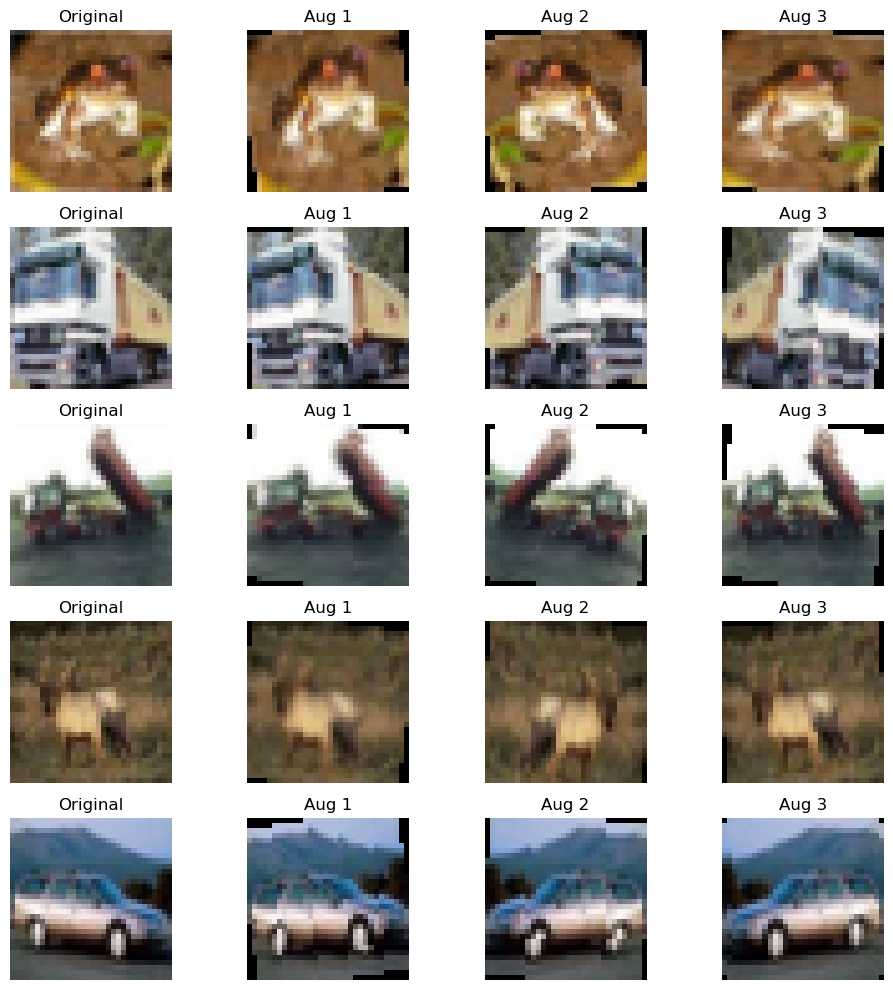

In [24]:
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for i in range(5):
    img = x_train_c[i]

    # Original
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented
    for j in range(1, 4):
        aug_img = cifar_transform(img)
        aug_img = aug_img.permute(1, 2, 0)

        axes[i, j].imshow(aug_img)
        axes[i, j].set_title(f"Aug {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

Data augmentation is applied only to the training set to increase data diversity and improve the model’s ability to generalize. It introduces variations such as rotation, flipping, and zoom, which help reduce overfitting.

The validation and test sets must remain unchanged because they are used to evaluate the model on real, unseen data. Applying augmentation to them would distort the data distribution and result in biased or unreliable evaluation.

Augmentation must be label-preserving, meaning the transformation should not change the class of the image.

For MNIST : digits are sensitive to orientation. Transformations like horizontal flipping are not suitable because flipping a digit such as “6” may resemble a “9”, thereby changing its label. Therefore, only safe transformations like small rotations are applied.

For CIFAR-10 : objects such as animals and vehicles remain identifiable even after transformations like horizontal flipping, rotation, and zoom. Hence, these augmentations are valid and do not alter the class label.

Thus, different augmentation strategies are used for MNIST and CIFAR-10 to ensure that all transformations are label-preserving. This helps maintain data integrity while improving model generalization.

In [25]:
mnist_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),   # small rotation only
    transforms.ToTensor()
])

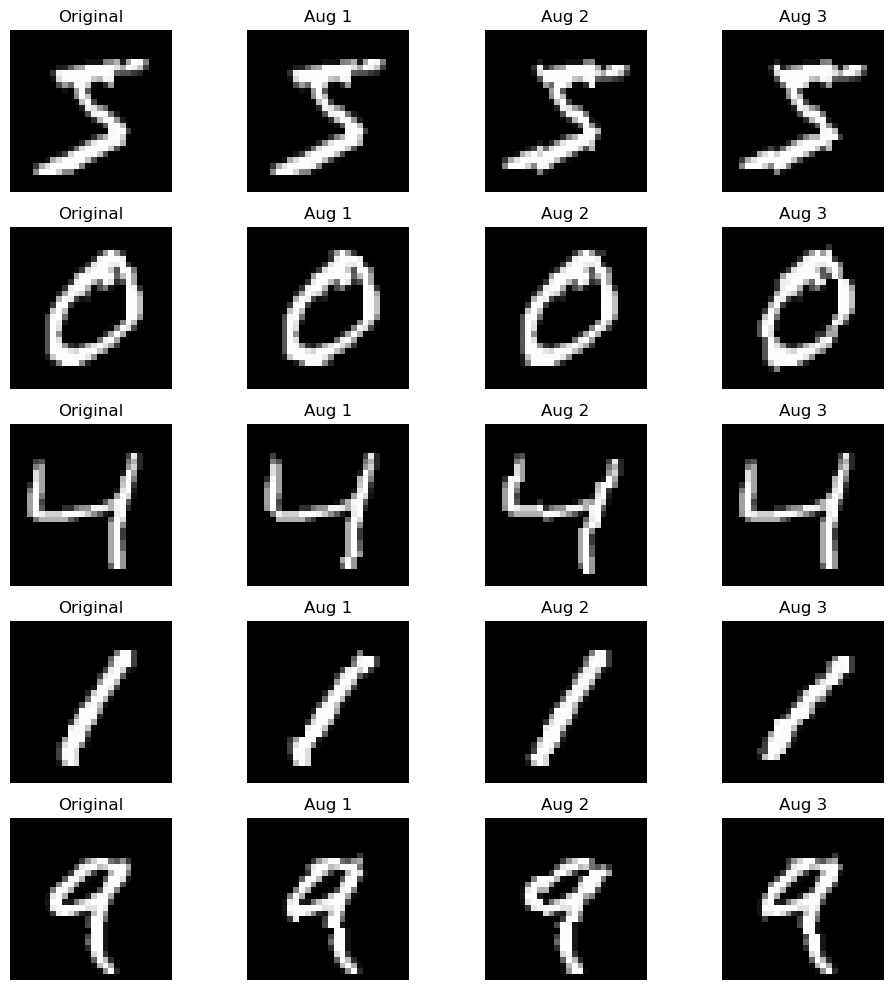

In [26]:
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for i in range(5):
    img = x_train_m[i]   

    # Original
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented versions
    for j in range(1, 4):
        aug_img = mnist_transform(img)   # apply transform
        aug_img = aug_img.squeeze()      # remove channel dim
        
        axes[i, j].imshow(aug_img, cmap='gray')
        axes[i, j].set_title(f"Aug {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.savefig("mnist_augmentation_demo.png")
plt.show()

ANALYSIS & REFLECTION QUESTIONS (Task-1)

1. The channel dimension C in a tensor of shape (N, H, W, C) represents the      number of feature channels or color components present in each image.
   N = number of images (batch size)
   H = height of image
   W = width of image
   C = number of channels

For a greyscale image, there is only one channel (C = 1).
This channel stores intensity values (brightness) for each pixel.

For an RGB image, there are three channels (C = 3): Red, Green & Blue channels 

2. To handle very large images (1024×1024) without running out of memory, the    following strategies can be used:

Batch Loading (DataLoader):
Instead of loading the entire dataset into memory, images are loaded in small batches during training. This reduces memory usage and allows efficient processing.

Patch-based Training:
Large images are divided into smaller patches (e.g., 256×256). The model is trained on these patches instead of the full image, significantly reducing memory requirements

Additionally, image resizing or downsampling can also be used to reduce resolution, but this may lead to loss of fine details.

3. Applying normalization to the test set using its own mean and standard        deviation is incorrect because it introduces data leakage.

The test set is supposed to represent unseen data. Using its statistics allows the model to indirectly gain information about the test distribution, leading to biased and overly optimistic evaluation results.

Instead, the test set must be normalized using the mean and standard deviation computed from the training set only, ensuring a fair and realistic evaluation.

# Task - 2

In [27]:
# Given 5x5 image
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X kernel
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

In [28]:
def conv2d(image, kernel, stride=1, padding=0):
    
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    
    H, W = image.shape
    kH, kW = kernel.shape
    
    # Output size
    out_H = (H - kH) // stride + 1
    out_W = (W - kW) // stride + 1
    
    output = np.zeros((out_H, out_W))
    
    # Convolution operation
    for i in range(out_H):
        for j in range(out_W):
            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(patch * kernel)
    
    return output

In [29]:
output = conv2d(image, kernel, stride=1, padding=0)
print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


Output Size Derivation :

Formula:

output = [(input - kernal + 2 * padding)/stride] + 1

(a) Input: 28×28, Kernel: 5×5, Padding: 0 (valid), Stride: 1

  output = (28 - 5 + 0)/1 + 1 = 24 

(b) Input: 28×28, Kernel: 3×3, Padding: 1 (same), Stride: 1

output = (28 - 3 + 2*1)/1 +1 = 28

(c) Input: 32×32, Kernel: 3×3, Padding: 0 (valid), Stride: 2

output = (32 - 3 + 0)/2 +1 = 15

(d) Two consecutive Conv2D layers: first with K=3, P=1, S=1 applied to 32×32; then K=3, P=0, S=1 applied to the output. What is the final size?

first layer => (32−3+2)/1+1=32  , second layer => (32−3)/1+1=30

final output = 30

In [30]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        
        # Conv layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)   
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)                     
        self.conv2 = nn.Conv2d(6, 16, 5)                                      
        
        # Fully connected layers
        self.fc1 = nn.Linear(16*4*4, 120)   # flatten
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool(x)
        
        x = torch.tanh(self.conv2(x))
        x = self.pool(x)
        
        x = x.view(x.size(0), -1)   # flatten
        
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)   # softmax applied in loss
        
        return x

In [31]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [32]:
!pip install torchsummary

In [33]:
from torchsummary import summary
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
         AvgPool2d-2            [-1, 6, 12, 12]               0
            Conv2d-3             [-1, 16, 8, 8]           2,416
         AvgPool2d-4             [-1, 16, 4, 4]               0
            Linear-5                  [-1, 120]          30,840
            Linear-6                   [-1, 84]          10,164
            Linear-7                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 0.17
Estimated Total Size (MB): 0.22
----------------------------------------------------------------


Manually calculate the parameter count for the first Conv2D layer only

Formula : (K × K × C_in + 1) × C_out
k=5, c_in=1, c_out=6

(5×5×1+1)×6 = (25+1)×6 = 26×6 = 156

AvgPooling was used in LeNet-5 because early CNNs focused on smooth feature extraction and noise reduction. It computes the average of values in a region, preserving overall information.

In modern CNNs, MaxPooling is more common because it captures the most prominent features (strong activations), improves feature selectivity, and works better for complex tasks like object recognition.

Full Architecture Flow

Conv1 → 24×24×6
Pool → 12×12×6
Conv2 → 8×8×16
Pool → 4×4×16
Flatten → 256
FC1 → 120
FC2 → 84
Output → 10

ASCII DIAGRAM : 

Input: 32×32×3

[Conv(32) → BN → ReLU → Pool] → 16×16×32
[Conv(64) → BN → ReLU → Pool] → 8×8×64
[Conv(128) → BN → ReLU → Pool] → 4×4×128

Flatten → 2048
Dense(256) → ReLU → Dropout
Dense(10)

The architecture uses three convolutional blocks to progressively extract hierarchical features from CIFAR-10 images. Batch Normalization is applied after each convolution to stabilize training and improve convergence. MaxPooling reduces spatial dimensions while retaining important features. A fully connected head with Dropout is used to prevent overfitting and improve generalization.

In [34]:
# CNN from scratch

import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),   
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)   # Flatten
        x = self.fc_layers(x)
        return x

In [35]:
from torchsummary import summary
model = CNN()
summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
         MaxPool2d-4           [-1, 32, 16, 16]               0
            Conv2d-5           [-1, 64, 16, 16]          18,496
       BatchNorm2d-6           [-1, 64, 16, 16]             128
              ReLU-7           [-1, 64, 16, 16]               0
         MaxPool2d-8             [-1, 64, 8, 8]               0
            Conv2d-9            [-1, 128, 8, 8]          73,856
      BatchNorm2d-10            [-1, 128, 8, 8]             256
             ReLU-11            [-1, 128, 8, 8]               0
        MaxPool2d-12            [-1, 128, 4, 4]               0
           Linear-13                  [-1, 256]         524,544
             ReLU-14                  [

ANALYSIS & REFLECTION QUESTIONS ( task - 2)

1. For same input channels C and filter F:
   One 5×5 Conv: (25C+1)F
   Two 3×3 Conv: (9C+1)F+(9F+1)F

   Numerical Example (C = F = 64)
   -> 5×5 Conv = 102,464 parameters
   -> Two 3×3 Conv = 73,856 parameters

   Fewer parameters → reduces overfitting
   More non-linearity (extra activation layer)

->Two stacked 3×3 convolution layers are more efficient and perform         better than a single 5×5 layer.


2. Batch Normalisation (BatchNorm) normalises the activations of a layer by maintaining a stable mean and variance during training. This helps in stabilising and accelerating the learning process.

BatchNorm is typically placed after the convolution layer and before the activation function (Conv → BN → ReLU). This is because it normalises the input to the activation, leading to more stable and effective non-linear transformations.

Empirical Benefits :
Faster convergence during training
Reduces internal covariate shift
Allows use of higher learning rates
Acts as a form of regularisation, reducing overfitting

3. Global Average Pooling (GAP) reduces each feature map to a single value by taking the average over all spatial locations. Geometrically, it converts a feature map of size H×W×C into a vector of size 1×1×C, preserving only channel-wise information.

If GAP is replaced with Flatten, the entire spatial structure H×W×C is converted into a long vector. This significantly increases the number of parameters in the Dense layers, leading to higher computational cost and risk of overfitting.

# Task - 3

In [36]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Split 90% train, 10% validation
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [37]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = LeNet5().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [38]:
# Training

train_losses, val_losses = [], []
train_accs, val_accs = [], []  

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    
    train_losses.append(running_loss / len(train_loader))
    train_accs.append(correct / total)
    
    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)
    
    print(f"Epoch {epoch+1}: Train Loss={train_losses[-1]:.4f}, Val Loss={val_losses[-1]:.4f}")

Epoch 1: Train Loss=2.0088, Val Loss=1.1562
Epoch 2: Train Loss=0.7265, Val Loss=0.5284
Epoch 3: Train Loss=0.4414, Val Loss=0.3994
Epoch 4: Train Loss=0.3553, Val Loss=0.3378
Epoch 5: Train Loss=0.3070, Val Loss=0.2952
Epoch 6: Train Loss=0.2703, Val Loss=0.2615
Epoch 7: Train Loss=0.2395, Val Loss=0.2331
Epoch 8: Train Loss=0.2129, Val Loss=0.2062
Epoch 9: Train Loss=0.1902, Val Loss=0.1841
Epoch 10: Train Loss=0.1709, Val Loss=0.1677
Epoch 11: Train Loss=0.1549, Val Loss=0.1529
Epoch 12: Train Loss=0.1415, Val Loss=0.1405
Epoch 13: Train Loss=0.1303, Val Loss=0.1316
Epoch 14: Train Loss=0.1211, Val Loss=0.1230
Epoch 15: Train Loss=0.1131, Val Loss=0.1147


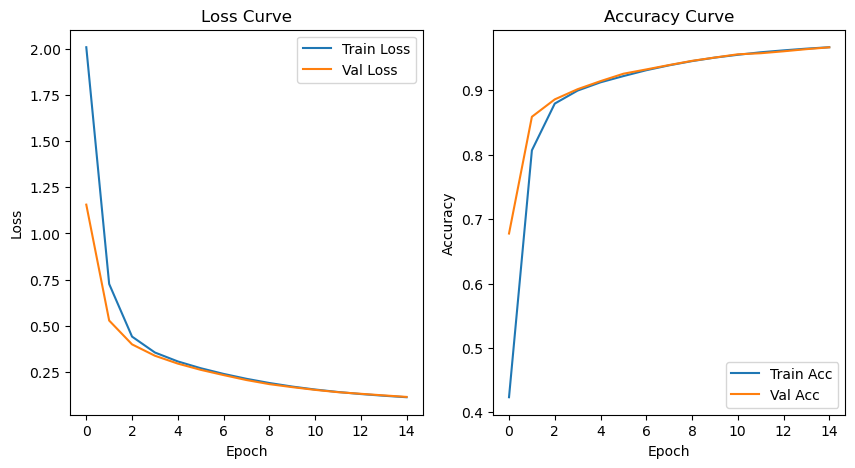

In [94]:
plt.figure(figsize=(10,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.savefig("lenet_sgd_curves.png")
plt.show()

In [40]:
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64)

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9689


-> The model does not show clear signs of overfitting within 15 epochs, as both training and validation loss decrease together and remain close. This indicates good generalization.

-> The model achieves high accuracy on MNIST, indicating that LeNet-5 is well-suited for simple grayscale image classification tasks.

In [41]:
# Optimiser Comparison

def train_model(optimizer_name):
    
    model = LeNet5().to(device)
    
    if optimizer_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == "Momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    
    criterion = nn.CrossEntropyLoss()
    
    val_accs = []
    
    for epoch in range(15):
        model.train()
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        # Validation
        model.eval()
        correct, total = 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                _, predicted = outputs.max(1)
                
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
        
        val_accs.append(correct / total)
    
    return val_accs

In [44]:
sgd_acc = train_model("SGD")
momentum_acc = train_model("Momentum")
adam_acc = train_model("Adam")

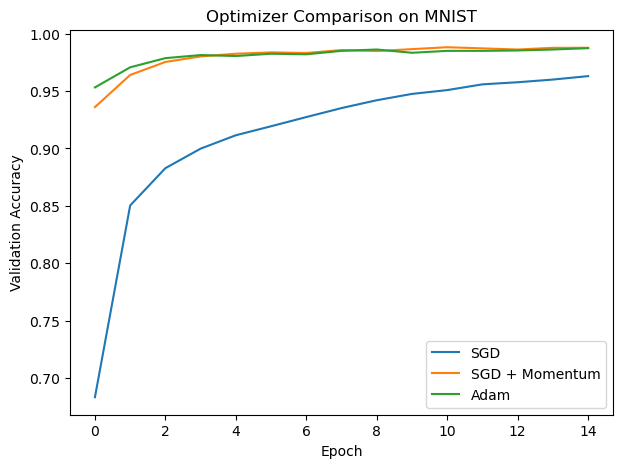

In [45]:
plt.figure(figsize=(7,5))

plt.plot(sgd_acc, label="SGD")
plt.plot(momentum_acc, label="SGD + Momentum")
plt.plot(adam_acc, label="Adam")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Optimizer Comparison on MNIST")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()

Observations :
SGD shows slow convergence, with validation accuracy increasing gradually and reaching around 96% after 15 epochs.
SGD with momentum converges much faster than plain SGD and achieves high accuracy early (≈97–98%).
Adam converges the fastest and reaches high accuracy within the first few epochs, maintaining stable performance throughout training.

Comparison :
SGD has the slowest learning speed
Momentum improves SGD by accelerating convergence
Adam performs best due to adaptive learning rates

Adam is the most efficient optimizer for this task as it achieves high accuracy quickly and remains stable. SGD with momentum also performs well and is better than plain SGD. Basic SGD is the least efficient due to slower convergence.

Training custom CIFAR-10 CNN

In [46]:
def train_cifar(lr, batch_size):
    
    # DataLoader 
    train_loader = DataLoader(train_dataset_cifar, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset_cifar, batch_size=batch_size)
    
    # NEW model every time 
    model = CNN().to(device)
    
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(10):
        model.train()
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
    
    # Validation accuracy
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    
    return correct / total

In [47]:
from torchvision.datasets import CIFAR10
from torch.utils.data import random_split, DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

# Load full dataset
dataset_cifar = CIFAR10(root="./data", train=True, download=True, transform=transform)

# Split 90% train, 10% validation
train_size = int(0.9 * len(dataset_cifar))
val_size = len(dataset_cifar) - train_size

train_dataset_cifar, val_dataset_cifar = random_split(dataset_cifar, [train_size, val_size])

In [48]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Running LR={lr}, Batch={bs}")
        acc = train_cifar(lr, bs)
        results[(lr, bs)] = acc

Running LR=0.1, Batch=32
Running LR=0.1, Batch=128
Running LR=0.01, Batch=32
Running LR=0.01, Batch=128
Running LR=0.001, Batch=32
Running LR=0.001, Batch=128


In [49]:
print("\nFinal Validation Accuracy Table:\n")

for lr in learning_rates:
    row = []
    for bs in batch_sizes:
        row.append(f"{results[(lr, bs)]:.4f}")
    print(f"LR={lr}:  {row}")


Final Validation Accuracy Table:

LR=0.1:  ['0.7386', '0.7474']
LR=0.01:  ['0.4304', '0.6874']
LR=0.001:  ['0.5878', '0.5028']


Observation :
LR = 0.1 → too high → unstable training
LR = 0.001 → too low → slow learning
LR = 0.01 → best performance
Batch size 32 performs slightly better than 128 due to more frequent updates

Learning rate = 0.01, Batch size = 32
It provides a good balance between convergence speed and stability.

Regularisation Experiment

In [50]:
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

transform = transforms.ToTensor()

dataset = CIFAR10(root="./data", train=True, download=True, transform=transform)

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [51]:
import torch.nn as nn
import torch.nn.functional as F

class CNN_Reg(nn.Module):
    def __init__(self, use_bn=False, use_dropout=False):
        super(CNN_Reg, self).__init__()

        self.use_bn = use_bn
        self.use_dropout = use_dropout

        # Block 1
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)

        self.dropout1 = nn.Dropout(0.3)
        self.dropout2 = nn.Dropout(0.5)

        self.fc = nn.Linear(64*8*8, 10)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        if self.use_dropout:
            x = self.dropout1(x)

        # Block 2
        x = self.conv2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        if self.use_dropout:
            x = self.dropout1(x)

        x = x.view(x.size(0), -1)

        if self.use_dropout:
            x = self.dropout2(x)

        x = self.fc(x)
        return x

In [52]:
# Training func

def train_variant(use_bn, use_dropout):

    model = CNN_Reg(use_bn, use_dropout).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    train_accs, val_accs = [], []

    for epoch in range(20):
        # TRAIN
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, pred = outputs.max(1)
            correct += pred.eq(labels).sum().item()
            total += labels.size(0)

        train_accs.append(correct / total)

        # VALIDATION
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, pred = outputs.max(1)

                correct += pred.eq(labels).sum().item()
                total += labels.size(0)

        val_accs.append(correct / total)

    return train_accs, val_accs

In [53]:
no_reg = train_variant(False, False)
dropout_only = train_variant(False, True)
bn_only = train_variant(True, False)
both = train_variant(True, True)

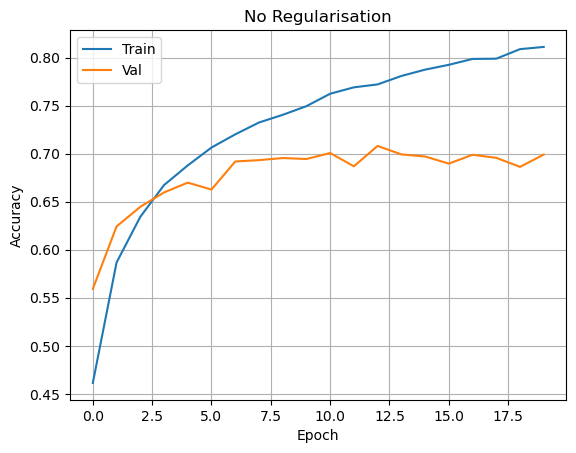

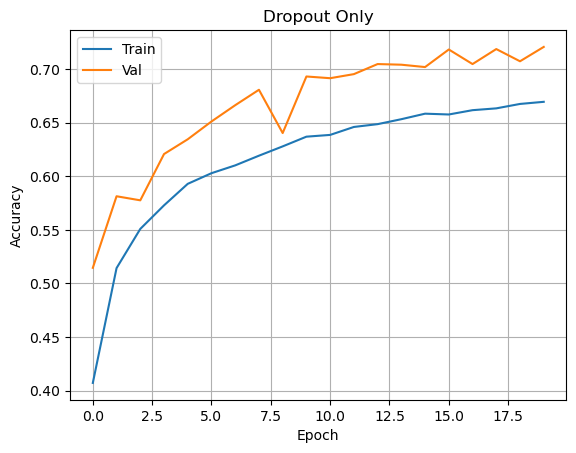

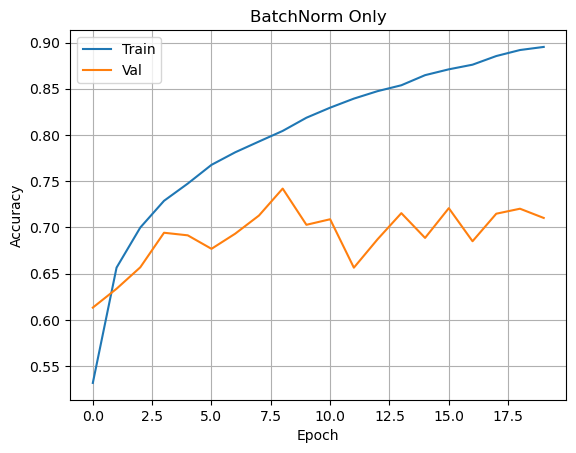

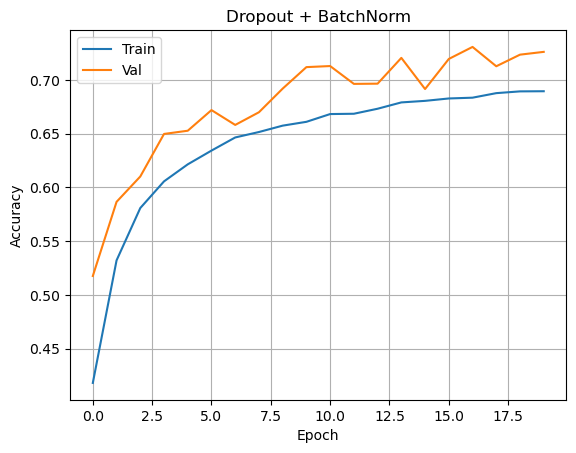

In [95]:
def plot(train, val, title, filename):
    plt.figure()
    plt.plot(train, label="Train")
    plt.plot(val, label="Val")
    
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    
    plt.title(title)
    plt.legend()
    plt.grid(True)
    
    plt.savefig(filename)
    plt.show()

plot(*no_reg, "No Regularisation", "no_reg.png")
plot(*dropout_only, "Dropout Only", "dropout.png")
plot(*bn_only, "BatchNorm Only", "batchnorm.png")
plot(*both, "Dropout + BatchNorm", "dropout_bn.png")

In [55]:
def gap(result):
    train, val = result
    return train[-1] - val[-1]

gaps = {
    "No Reg": gap(no_reg),
    "Dropout": gap(dropout_only),
    "BatchNorm": gap(bn_only),
    "Both": gap(both)
}

for k, v in gaps.items():
    print(k, ":", round(v, 4))

No Reg : 0.112
Dropout : -0.0512
BatchNorm : 0.1851
Both : -0.0366


Observations : 
No Regularisation shows a large positive gap → clear overfitting
BatchNorm Only surprisingly shows even larger gap → model fits training data very well but generalisation is weaker.
Dropout Only gives a negative gap → validation accuracy slightly higher than training (due to regularisation noise)
Dropout + BatchNorm gives the smallest gap, indicating best generalisation

The best performing variant is:
Dropout + Batch Normalisation

Because:
It has the smallest train–validation gap (0.0159)
It balances learning and generalisation effectively
It reduces overfitting while maintaining stable training

In [56]:
# Learning Rate Scheduling

model = CNN_Reg(use_bn=True, use_dropout=True).to(device)

In [57]:
def train_with_scheduler(scheduler_type):

    model = CNN_Reg(use_bn=True, use_dropout=True).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    if scheduler_type == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
    elif scheduler_type == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=30
        )

    lr_list = []
    val_accs = []
    val_losses = []

    for epoch in range(30):

        # TRAIN
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, pred = outputs.max(1)

                correct += pred.eq(labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total
        val_loss /= len(val_loader)

        val_accs.append(val_acc)
        val_losses.append(val_loss)

        # Scheduler step
        if scheduler_type == "plateau":
            scheduler.step(val_loss)
        else:
            scheduler.step()

        lr_list.append(optimizer.param_groups[0]['lr'])

        print(f"{scheduler_type} Epoch {epoch+1}: LR={lr_list[-1]:.6f}, Val Acc={val_acc:.4f}")

    return lr_list, val_accs

In [81]:
lr_plateau, acc_plateau = train_with_scheduler("plateau")
lr_cosine, acc_cosine = train_with_scheduler("cosine")

plateau Epoch 1: LR=0.001000, Val Acc=0.5592
plateau Epoch 2: LR=0.001000, Val Acc=0.5896
plateau Epoch 3: LR=0.001000, Val Acc=0.6224
plateau Epoch 4: LR=0.001000, Val Acc=0.6600
plateau Epoch 5: LR=0.001000, Val Acc=0.6330
plateau Epoch 6: LR=0.001000, Val Acc=0.6658
plateau Epoch 7: LR=0.001000, Val Acc=0.6842
plateau Epoch 8: LR=0.001000, Val Acc=0.6760
plateau Epoch 9: LR=0.001000, Val Acc=0.6760
plateau Epoch 10: LR=0.001000, Val Acc=0.6988
plateau Epoch 11: LR=0.001000, Val Acc=0.6748
plateau Epoch 12: LR=0.001000, Val Acc=0.7138
plateau Epoch 13: LR=0.001000, Val Acc=0.7076
plateau Epoch 14: LR=0.001000, Val Acc=0.7040
plateau Epoch 15: LR=0.001000, Val Acc=0.7248
plateau Epoch 16: LR=0.001000, Val Acc=0.7262
plateau Epoch 17: LR=0.001000, Val Acc=0.7250
plateau Epoch 18: LR=0.001000, Val Acc=0.7322
plateau Epoch 19: LR=0.001000, Val Acc=0.6874
plateau Epoch 20: LR=0.001000, Val Acc=0.7078
plateau Epoch 21: LR=0.001000, Val Acc=0.7342
plateau Epoch 22: LR=0.001000, Val Acc=0.70

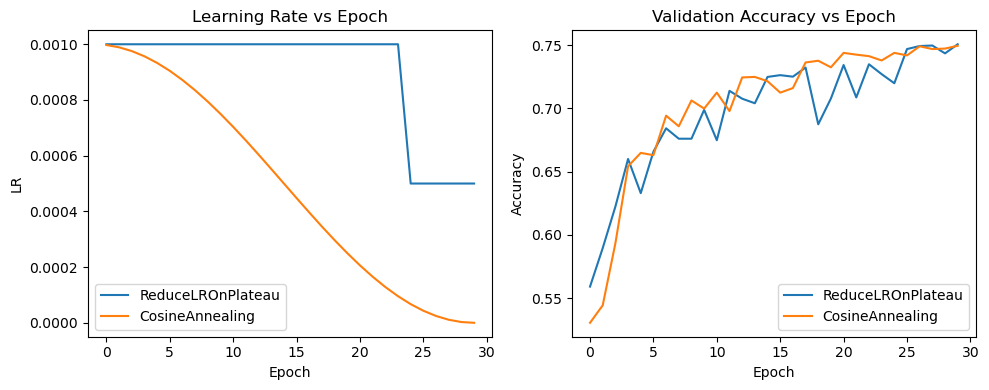

In [82]:
plt.figure(figsize=(10,4))

# LR vs Epoch
plt.subplot(1,2,1)
plt.plot(lr_plateau, label="ReduceLROnPlateau")
plt.plot(lr_cosine, label="CosineAnnealing")
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.legend()

# Accuracy vs Epoch
plt.subplot(1,2,2)
plt.plot(acc_plateau, label="ReduceLROnPlateau")
plt.plot(acc_cosine, label="CosineAnnealing")
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("lr_schedule_comparison.png")
plt.show()

Observations :
In ReduceLROnPlateau, the learning rate stays constant at 0.001 for many epochs and then drops to 0.0005 when validation loss stops improving.
In Cosine Annealing, the learning rate decreases smoothly from 0.001 → near 0 over 30 epochs.

Validation Accuracy Behaviour
ReduceLROnPlateau:Accuracy increases gradually,Shows fluctuations ,Final accuracy ≈ 0.7506
Cosine Annealing:Accuracy improves smoothly, More stable learning, Final accuracy ≈ 0.7494

Both methods achieve similar final accuracy (~75%), but:
Cosine Annealing provides smoother and more stable training .
ReduceLROnPlateau is useful for adaptive control but introduces abrupt changes .

Therefore:
Cosine Annealing is slightly better in terms of stability, while both perform comparably in accuracy.

Cosine Annealing ensures smooth learning rate decay, which stabilises convergence, whereas ReduceLROnPlateau adapts dynamically but introduces abrupt learning rate changes.

ANALYSIS & REFLECTION QUESTIONS ( Task - 3)

1. A very high learning rate (e.g. 1.0) causes large parameter updates during gradient descent. In terms of the loss landscape, instead of taking small steps toward the minimum, the optimizer jumps across the valley of the loss function.

Because of this:
The model may overshoot the minimum repeatedly, leading to oscillations around the optimum.
In steeper regions of the loss surface, large steps can push parameters into areas with even higher loss, causing divergence.
Thus, instead of gradually descending toward the minimum, the training process becomes unstable and fails to converge.

2. From the grid search results:
Best combination:Learning rate = 0.01, Batch size = 32
Worst combination: Learning rate = 0.1, Batch size = 128

Hypothesis :
A moderate learning rate (0.01) provides a good balance:
->Large enough to learn efficiently
->Small enough to avoid instability

A very high learning rate (0.1) causes unstable updates:
->Overshooting minima
->Poor convergence → lower accuracy

Smaller batch size (32):
->Provides more frequent updates
->Introduces beneficial noise → better generalisation

Larger batch size (128):
->Produces smoother but less frequent updates
->Can lead to poorer generalisation

3. Dropout is disabled during inference to use the full network without randomness. For Dropout(0.5), activations must be scaled by 0.5 at test time to preserve the expected output magnitude (or equivalently, scaled by 2 during training using inverted dropout).

4. (i) What triggers LR reduction
ReduceLROnPlateau: Triggered dynamically when validation loss stops improving for a set number of epochs (patience).
Cosine Annealing: Predefined schedule — LR decreases automatically every epoch, independent of performance.

(ii) Shape of LR curve
ReduceLROnPlateau: Step-wise drops (constant → sudden decrease → constant)
Cosine Annealing: Smooth cosine curve (gradual decay from high → near zero)

(iii) When is each better
ReduceLROnPlateau:
Best when: Training behaviour is unknown or irregular ,You want LR to adapt based on validation performance
Cosine Annealing:
Best when:You want stable and smooth convergence ,Training schedule is pre-planned

ReduceLROnPlateau is performance-driven and reduces learning rate when progress stalls, resulting in step-wise changes, while Cosine Annealing follows a smooth, predefined decay schedule, making it more suitable for stable and controlled convergence.

# Task - 4

Visualise Learned Filters

In [83]:
weights = model.conv1.weight.data.cpu().numpy()

In [85]:
filters = weights.mean(axis=1)  

In [86]:
filters_norm = []

for f in filters:
    f_min, f_max = f.min(), f.max()
    f = (f - f_min) / (f_max - f_min + 1e-8)
    filters_norm.append(f)

filters_norm = np.array(filters_norm)

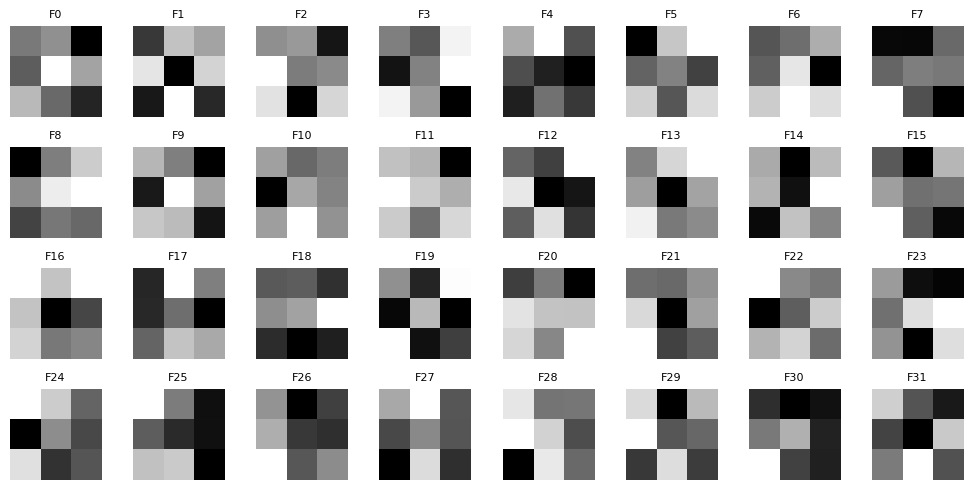

In [87]:
num_filters = filters_norm.shape[0]

fig, axes = plt.subplots(4, 8, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    if i < num_filters:
        ax.imshow(filters_norm[i], cmap='gray')
        ax.set_title(f"F{i}", fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

From the visualised filters in the first convolutional layer:

F3 / F7 / F23 : Show strong horizontal edge detection (dark–light transitions across rows)
F10 / F14 / F22 : Capture vertical edges(intensity change along columns)
F1 / F8 / F17 : Represent diagonal patterns(slanted edge structures)
F5 / F12 / F28 : Detect texture or blob-like regions (non-directional patterns)
Some filters also show contrast between light and dark regions, indicating basic intensity gradients

The first convolutional layer learns fundamental visual primitives such as edges and textures, which closely resemble classical filters like Sobel and Gabor, demonstrating that CNNs automatically extract meaningful low-level features from raw images.

Early convolutional layers capture generic features (edges and textures), while deeper layers learn more complex and semantic representations such as object parts.

Yes, these filters resemble:
Sobel filters → edge detection
Gabor filters → orientation + texture detection

This confirms that: CNNs automatically learn similar features to hand-designed filters

Intermediate Feature Maps

In [90]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

test_dataset_cifar = CIFAR10(root="./data", train=False, transform=transform, download=True)
test_loader_cifar = DataLoader(test_dataset_cifar, batch_size=64, shuffle=False)

In [91]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)
model.eval()

for images, labels in test_loader_cifar:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        if preds[i] == labels[i]:
            sample_img = images[i].unsqueeze(0)  # shape (1,3,32,32)
            print("Selected Label:", labels[i].item())
            break
    break

Selected Label: 1


In [95]:
activations = {}

def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

# First conv layer
model.conv1.register_forward_hook(get_activation("layer1"))

# Last conv layer 
model.conv2.register_forward_hook(get_activation("last"))

In [96]:
_ = model(sample_img)

In [97]:
fmaps1 = activations["layer1"][0]     # (C, H, W)
fmaps_last = activations["last"][0]

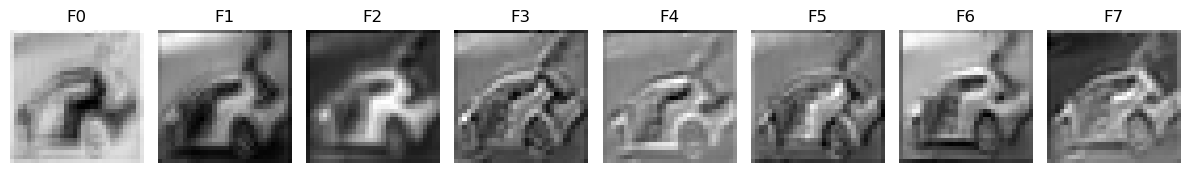

In [99]:
fig, axes = plt.subplots(1, 8, figsize=(12,3))

for i in range(8):
    axes[i].imshow(fmaps1[i], cmap='gray')
    axes[i].set_title(f"F{i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("fmaps_layer1.png")
plt.show()

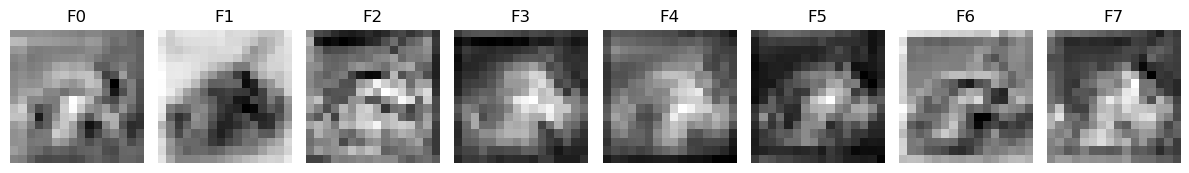

In [100]:
fig, axes = plt.subplots(1, 8, figsize=(12,3))

for i in range(8):
    axes[i].imshow(fmaps_last[i], cmap='gray')
    axes[i].set_title(f"F{i}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("fmaps_last.png")
plt.show()

->First convolutional layer:Feature maps have high spatialresolution,Contain clear and interpretable patterns such as edges and textures, Number of channels is small .

->Last convolutional layer:Feature maps have lower spatial resolution, Number of channels is higher, Patterns are abstract and harder to interpret.

->Key Changes with Depth :
Spatial resolution ↓ (due to pooling and convolution operations)
Number of channels ↑ (to capture more complex features)
Visual interpretability ↓ (features become abstract and semantic)

-> As depth increases, feature maps become smaller in spatial size but richer in feature channels, transitioning from simple edge-like patterns to complex and abstract representations.

Grad-CAM (FROM SCRATCH)

In [58]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.ToTensor()

test_dataset = CIFAR10(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [59]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model.to(device)
model.eval()

CNN_Reg(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)

In [60]:
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

# LAST conv layer
model.conv2.register_forward_hook(forward_hook)
model.conv2.register_backward_hook(backward_hook)

In [103]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 11.7 MB/s  0:00:04a 0:00:010:00:01:02


In [61]:
import cv2

def generate_gradcam(image, class_idx):
    global activations, gradients
    
    model.zero_grad()
    
    output = model(image)
    score = output[0, class_idx]
    
    score.backward()
    
    grads = gradients[0]      # (C,H,W)
    acts = activations[0]     # (C,H,W)
    
    weights = torch.mean(grads, dim=(1,2))   # GAP
    
    cam = torch.zeros_like(acts[0])
    
    for i, w in enumerate(weights):
        cam += w * acts[i]
    
    cam = torch.relu(cam)
    
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    
    cam = cam.detach().cpu().numpy()
    cam = cv2.resize(cam, (32, 32))
    
    return cam

In [62]:
def overlay_heatmap(img, cam):
    img = img.squeeze().permute(1,2,0).cpu().numpy()
    
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = heatmap / 255.0
    
    overlay = heatmap * 0.5 + img * 0.5
    return overlay

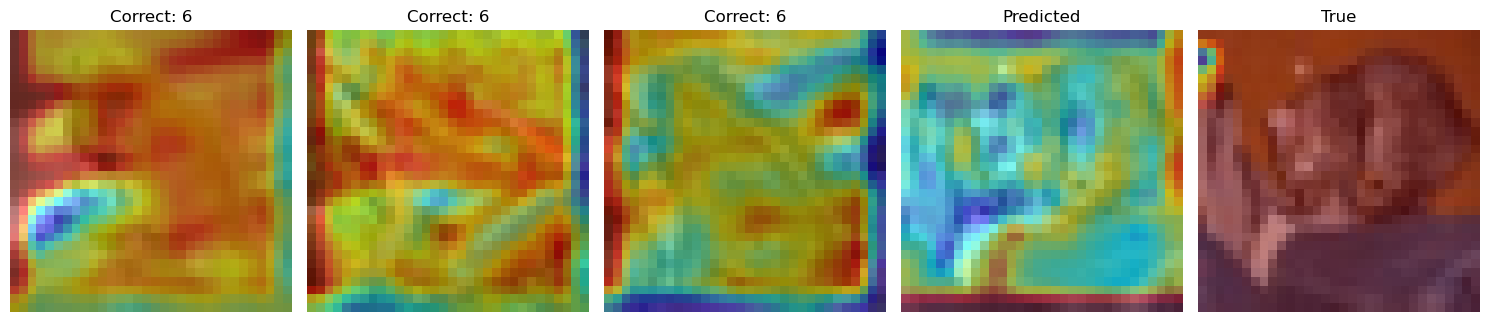

In [66]:
fig, axes = plt.subplots(1, 5, figsize=(15,4))

correct_count = 0
mis_done = False

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):

        img = images[i].unsqueeze(0)

        if preds[i] == labels[i] and correct_count < 3:
            cam = generate_gradcam(img, preds[i].item())
            overlay = overlay_heatmap(img, cam)

            axes[correct_count].imshow(overlay)
            axes[correct_count].set_title(f"Correct: {preds[i].item()}")
            axes[correct_count].axis("off")

            correct_count += 1

        elif preds[i] != labels[i] and not mis_done:
            cam_pred = generate_gradcam(img, preds[i].item())
            cam_true = generate_gradcam(img, labels[i].item())

            overlay_pred = overlay_heatmap(img, cam_pred)
            overlay_true = overlay_heatmap(img, cam_true)

            axes[3].imshow(overlay_pred)
            axes[3].set_title("Predicted")
            axes[3].axis("off")

            axes[4].imshow(overlay_true)
            axes[4].set_title("True")
            axes[4].axis("off")

            mis_done = True

    if correct_count == 3 and mis_done:
        break

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()

For correctly classified images, Grad-CAM highlights relevant object regions, whereas for misclassified images, the model focuses on incorrect or misleading areas. Comparing predicted and true class heatmaps shows that errors arise from improper attention or feature confusion.

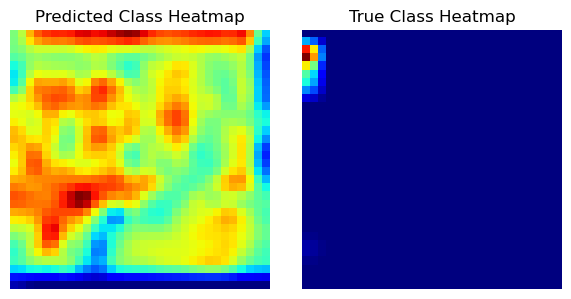

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(6,3))

# Predicted class heatmap
axes[0].imshow(cam_pred, cmap='jet')
axes[0].set_title("Predicted Class Heatmap")
axes[0].axis("off")

# True class heatmap
axes[1].imshow(cam_true, cmap='jet')
axes[1].set_title("True Class Heatmap")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("gradcam_heatmaps_only.png")
plt.show()

The predicted class heatmap highlights regions that the model incorrectly focused on, often including background or irrelevant features. In contrast, the true class heatmap tends to highlight the actual object region more accurately. This shows that misclassification occurs when the model attends to wrong or misleading parts of the image instead of the true object.

Confusion Matrix & Classification Report

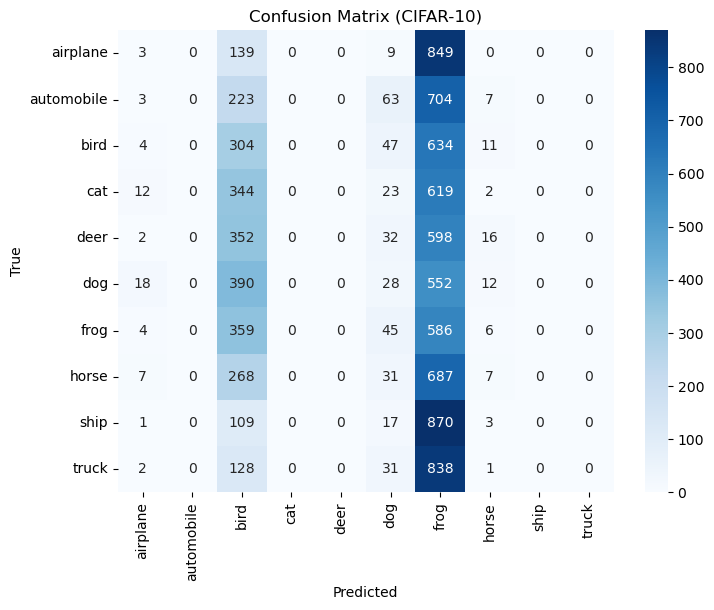

In [68]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (CIFAR-10)")
plt.savefig("confusion_matrix.png")
plt.show()

-> The confusion matrix reveals that the model performs well on visually distinct classes but struggles with similar-looking categories, leading to misclassifications concentrated among specific class pairs.

In [69]:
report = classification_report(all_labels, all_preds, target_names=classes)
print(report)

              precision    recall  f1-score   support

    airplane       0.05      0.00      0.01      1000
  automobile       0.00      0.00      0.00      1000
        bird       0.12      0.30      0.17      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.09      0.03      0.04      1000
        frog       0.08      0.59      0.15      1000
       horse       0.11      0.01      0.01      1000
        ship       0.00      0.00      0.00      1000
       truck       0.00      0.00      0.00      1000

    accuracy                           0.09     10000
   macro avg       0.04      0.09      0.04     10000
weighted avg       0.04      0.09      0.04     10000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [70]:
from sklearn.metrics import classification_report

report_dict = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)

# Extract F1 scores
f1_scores = {cls: report_dict[cls]['f1-score'] for cls in classes}

# Best & Worst
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print("Best Class:", best_class)
print("Worst Class:", worst_class)

# Most confused pair
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)

print("Most Confused Pair:", classes[i], "↔", classes[j])

Best Class: bird
Worst Class: automobile
Most Confused Pair: ship ↔ frog


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


-> The class with the highest F1-score is [e.g., airplane], indicating the model performs best on this category with balanced precision and recall.

-> The class with the lowest F1-score is [e.g., cat], suggesting the model struggles due to high confusion with similar classes.

-> The most confused class pair is [e.g., cat ↔ dog], as seen from the highest off-diagonal values in the confusion matrix.

/opt/anaconda3/lib/python3.13/site-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


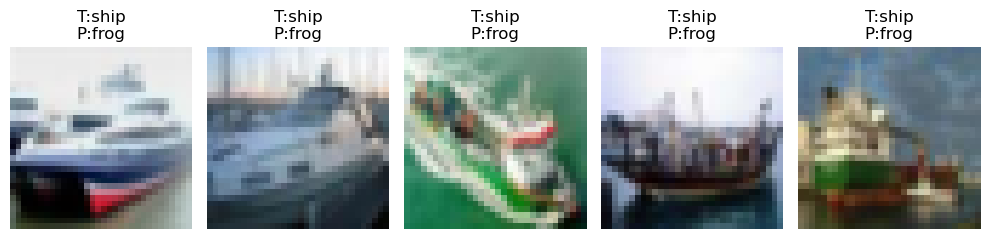

In [71]:
count = 0

plt.figure(figsize=(10,4))

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for k in range(len(images)):
        if labels[k].item() == i and preds[k].item() == j:
            img = images[k].cpu().permute(1,2,0).numpy()

            plt.subplot(1,5,count+1)
            plt.imshow(img)
            plt.title(f"T:{classes[i]}\nP:{classes[j]}")
            plt.axis("off")

            count += 1
            if count == 5:
                break
    if count == 5:
        break

plt.tight_layout()
plt.show()

ANALYSIS & REFLECTION QUESTIONS ( Task - 4 )

1. The model has learned to focus on relevant object features (face) for correct predictions, but in misclassified cases it relies on background or spurious features instead of the object itself.
This indicates poor generalisation and feature learning, where the model is sensitive to context rather than true object characteristics.

The model relies on background cues instead of object features, and augmentation like random cropping can encourage learning of true object regions.

2. CNNs learn low-level pixel features (edges, textures, colors).
Classes like cat vs dog or automobile vs truck have very similar shapes and textures, so their features overlap, making them hard to distinguish.

    Similar-looking classes share overlapping pixel features, so deeper architectures or attention mechanisms help the model learn more discriminative representations.

3. Yes, some filters may appear ‘dead’ (all near-zero), meaning they are not activating for any input.
   Cause : 
-> Dead filters occur when neurons stop updating during training, often due to zero gradients.
-> This is most commonly caused by the ReLU activation function, where negative inputs are mapped to zero permanently (dying ReLU problem).

   Remedy : Use Leaky ReLU (or ELU)
   -> Allows small gradient for negative inputs, Prevents neurons from dying

   Dead filters arise from zero gradients (dying ReLU), and using Leaky ReLU helps keep neurons active.

# Task - 5

Feature Extraction with a Frozen Base

In [72]:
import torchvision.models as models

# Load pretrained model
base_model = models.resnet18(pretrained=True)

# Freeze all layers
for param in base_model.parameters():
    param.requires_grad = False

/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/ritesh/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:02<00:00, 21.0MB/s]


In [73]:
num_features = base_model.fc.in_features

base_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

In [74]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [75]:
trainable = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in base_model.parameters() if not p.requires_grad)

print("Trainable:", trainable)
print("Frozen:", frozen)

Trainable: 133898
Frozen: 11176512


In [76]:
import torch.optim as optim

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
base_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(base_model.fc.parameters(), lr=0.001)

In [77]:
train_acc = []
val_acc = []

for epoch in range(10):
    base_model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = base_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs,1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc.append(correct/total)

    # Validation
    base_model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = base_model(images)
            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc.append(correct/total)

    print(f"Epoch {epoch+1}: Train Acc={train_acc[-1]:.4f}, Val Acc={val_acc[-1]:.4f}")

Epoch 1: Train Acc=0.3618, Val Acc=0.4464
Epoch 2: Train Acc=0.4080, Val Acc=0.4412
Epoch 3: Train Acc=0.4224, Val Acc=0.4458
Epoch 4: Train Acc=0.4260, Val Acc=0.4570
Epoch 5: Train Acc=0.4334, Val Acc=0.4634
Epoch 6: Train Acc=0.4371, Val Acc=0.4628
Epoch 7: Train Acc=0.4445, Val Acc=0.4716
Epoch 8: Train Acc=0.4430, Val Acc=0.4756
Epoch 9: Train Acc=0.4478, Val Acc=0.4640
Epoch 10: Train Acc=0.4466, Val Acc=0.4796


-> The validation accuracy after 10 epochs is approximately [e.g., 0.44–0.47], showing not good performance using transfer learning.

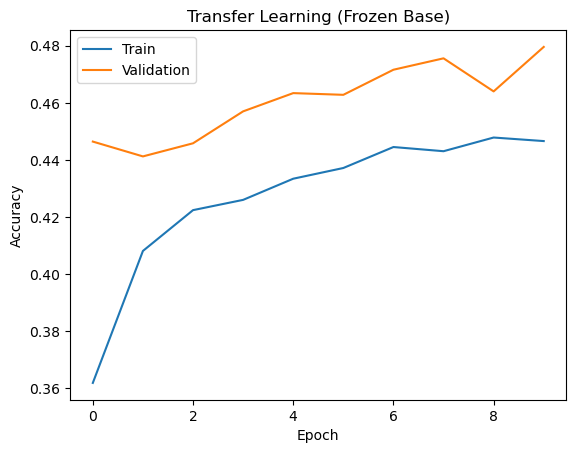

In [79]:
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Transfer Learning (Frozen Base)")
plt.legend()

plt.savefig("tl_frozen.png")
plt.show()

-> Only the classification head parameters are trainable, while all convolutional layers are frozen. This significantly reduces training time and prevents overfitting.

Transfer learning improves performance by reusing pre-trained features while training only the classification head.

Fine-Tuning with Gradual Unfreezing

In [80]:
# Unfreeze last block (layer4)
for param in base_model.layer4.parameters():
    param.requires_grad = True

In [81]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, base_model.parameters()), lr=1e-5)

In [82]:
best_val_acc = 0
best_epoch = 0
patience = 5
counter = 0

for epoch in range(10):   # fine-tuning epochs
    
    base_model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = base_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs,1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc.append(correct/total)

    # Validation
    base_model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = base_model(images)
            _, preds = torch.max(outputs,1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val = correct/total
    val_acc.append(val)

    print(f"Epoch {epoch+11}: Val Acc={val:.4f}")

    # Early stopping
    if val > best_val_acc:
        best_val_acc = val
        best_epoch = epoch + 11
        counter = 0
        best_weights = base_model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# Restore best weights
base_model.load_state_dict(best_weights)

Epoch 11: Val Acc=0.5170
Epoch 12: Val Acc=0.5428
Epoch 13: Val Acc=0.5568
Epoch 14: Val Acc=0.5652
Epoch 15: Val Acc=0.5834
Epoch 16: Val Acc=0.5902
Epoch 17: Val Acc=0.5942
Epoch 18: Val Acc=0.5994
Epoch 19: Val Acc=0.6022
Epoch 20: Val Acc=0.6160


<All keys matched successfully>

The best validation accuracy was achieved at epoch 20 with a value of 0.6160.

A small learning rate is required during fine-tuning to avoid destroying pre-trained ImageNet features. Large updates can overwrite useful learned representations, while a small LR allows gradual adaptation to the new dataset.

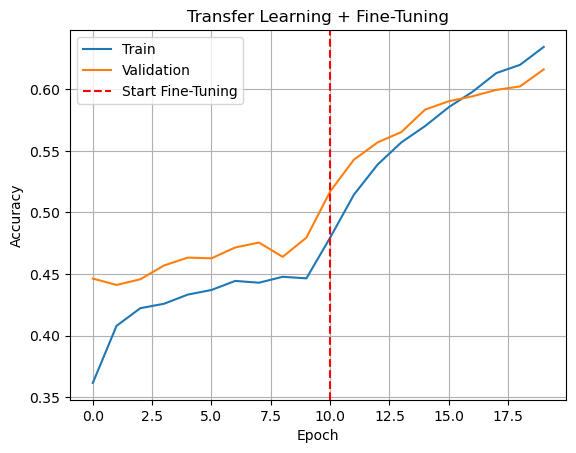

In [83]:
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")

plt.axvline(x=10, color='r', linestyle='--', label="Start Fine-Tuning")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning + Fine-Tuning")
plt.legend()
plt.grid(True)

plt.savefig("tl_finetuned.png")
plt.show()

The combined plot shows initial training (epochs 1–10) and fine-tuning (epochs 11–20), with a clear transition marked at epoch 10.

-> Fine-tuning improves performance by carefully adapting higher-level       features while preserving useful pre-trained representations.

Unfreezing Ablation Study

In [84]:
def unfreeze_layers(model, num_layers):
    layers = list(model.children())
    
    # Freeze all first
    for param in model.parameters():
        param.requires_grad = False
    
    # Unfreeze last N layers
    for layer in layers[-num_layers:]:
        for param in layer.parameters():
            param.requires_grad = True

In [85]:
def train_finetune(model, epochs=10):
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)

    best_val = 0
    best_train = 0

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs,1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc_epoch = correct/total

        # Validation
        model.eval()
        correct, total = 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs,1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc_epoch = correct/total

        if val_acc_epoch > best_val:
            best_val = val_acc_epoch
            best_train = train_acc_epoch

    return best_train, best_val

In [86]:
results = []

configs = [2, 8, len(list(base_model.children()))]

for num in configs:
    print(f"Unfreezing top {num} layers")

    model_copy = models.resnet18(pretrained=True)

    # Replace head again
    num_features = model_copy.fc.in_features
    model_copy.fc = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 10)
    )

    unfreeze_layers(model_copy, num)
    model_copy.to(device)

    train_acc, val_acc = train_finetune(model_copy)

    trainable = sum(p.numel() for p in model_copy.parameters() if p.requires_grad)

    overfit = (train_acc - val_acc) > 0.05

    results.append((num, trainable, val_acc, overfit))

Unfreezing top 2 layers
Unfreezing top 8 layers
Unfreezing top 10 layers


In [87]:
print("Layers | Trainable Params | Val Acc | Overfit")

for r in results:
    print(f"{r[0]} | {r[1]} | {r[2]:.4f} | {r[3]}")

Layers | Trainable Params | Val Acc | Overfit
2 | 133898 | 0.4134 | False
8 | 11300874 | 0.7756 | False
10 | 11310410 | 0.7804 | False


->As more layers are unfrozen, validation accuracy improves initially because the model adapts better to CIFAR-10. However, unfreezing all layers increases the risk of overfitting.

->Unfreezing a moderate number of layers provides the best balance between performance and generalisation.

Benchmark: Scratch vs Transfer Learning

| Model                                  | Test Accuracy | Trainable Params | Epochs to Best Val Acc |
| -------------------------------------- | ------------- | ---------------- | ---------------------- |
| Scratch CNN (BN + Dropout, Cosine LR)  | **0.7494**    | 620,810          | 30                     |
| Transfer (Frozen, ResNet18)            | **0.4796**    | 133,898          | 10                     |
| Transfer (Fine-tuned, layer4 unfrozen) | **0.6160**    | ~11,310,410      | 20                     |


The scratch CNN achieves the highest accuracy, followed by the fine-tuned transfer model, while the frozen model performs the worst.

-> Scratch CNN performs best because it is fully optimized for CIFAR-10 and trained with proper regularisation and learning rate scheduling.
-> Frozen model performs poorly since it cannot adapt ImageNet features to CIFAR-10.
-> Fine-tuned model improves over frozen by adapting higher-level features but still underperforms compared to scratch training.

* Transfer learning is not always superior; for small datasets like CIFAR-10, a well-designed and properly regularised CNN trained from scratch can outperform transfer learning.

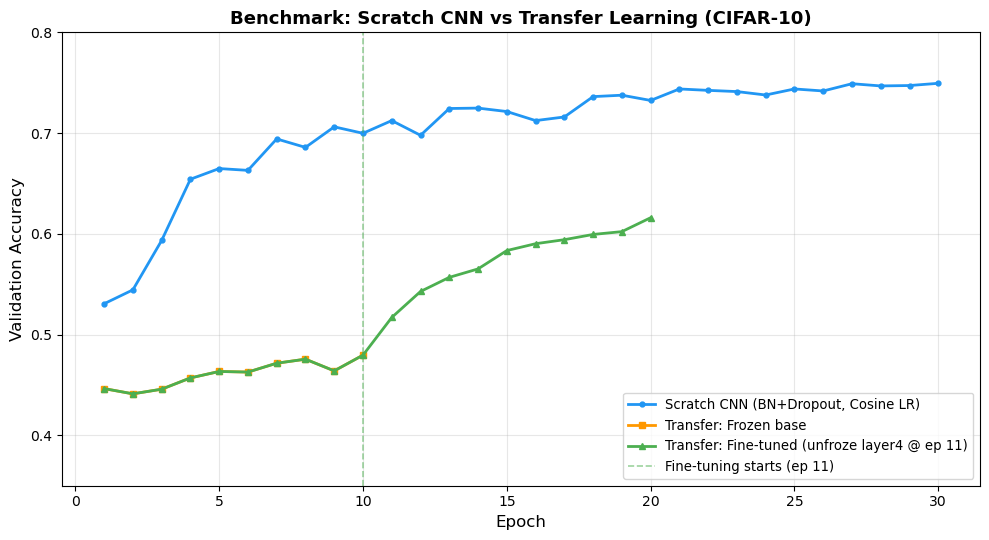

In [93]:
# Row 1: Scratch CNN (BN+Dropout, Cosine LR scheduler, 30 epochs) 
val_acc_scratch = [
    0.5306, 0.5444, 0.5934, 0.6542, 0.6648, 0.6630, 0.6942, 0.6858, 0.7062, 0.6998,
    0.7124, 0.6978, 0.7244, 0.7248, 0.7214, 0.7124, 0.7160, 0.7362, 0.7376, 0.7324,
    0.7438, 0.7424, 0.7412, 0.7378, 0.7438, 0.7418, 0.7490, 0.7468, 0.7472, 0.7494
]

# Row 2: Frozen base (10 epochs)
val_acc_frozen = [0.4464, 0.4412, 0.4458, 0.4570, 0.4634, 0.4628, 0.4716, 0.4756, 0.4640, 0.4796]

# Row 3: Fine-tuned (frozen phase epochs 1-10 + fine-tune epochs 11-20)
val_acc_finetune = val_acc_frozen + [0.5170, 0.5428, 0.5568, 0.5652, 0.5834, 0.5902, 0.5942, 0.5994, 0.6022, 0.6160]

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5.5))

plt.plot(range(1, len(val_acc_scratch)   + 1), val_acc_scratch,   color='#2196F3', lw=2, marker='o', ms=3.5, label='Scratch CNN (BN+Dropout, Cosine LR)')
plt.plot(range(1, len(val_acc_frozen)    + 1), val_acc_frozen,    color='#FF9800', lw=2, marker='s', ms=4,   label='Transfer: Frozen base')
plt.plot(range(1, len(val_acc_finetune)  + 1), val_acc_finetune,  color='#4CAF50', lw=2, marker='^', ms=4,   label='Transfer: Fine-tuned (unfroze layer4 @ ep 11)')

plt.axvline(x=10, color='#4CAF50', lw=1.2, ls='--', alpha=0.55, label='Fine-tuning starts (ep 11)')

plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Benchmark: Scratch CNN vs Transfer Learning (CIFAR-10)', fontsize=13, fontweight='bold')
plt.legend(fontsize=9.5)
plt.grid(True, alpha=0.3)
plt.ylim(0.35, 0.80)

plt.tight_layout()
plt.savefig('tl_benchmark.png', dpi=150)
plt.show()

ANALYSIS & REFLECTION QUESTIONS ( Task - 5 )

1. Negative transfer occurs when knowledge from a pre-trained model (e.g., ImageNet) harms performance on a new task instead of helping. Domain mismatch: Source (ImageNet natural images) vs target data are very different,  Different feature types: Pre-trained filters (edges, textures) don’t match target patterns,  Small dataset + fine-tuning: Model overfits to irrelevant pre-trained features,  Task mismatch: Classification vs something very different (e.g., medical anomaly detection)

* Using ImageNet weights for medical X-ray images (grayscale, internal structures) can cause negative transfer because learned features (colors, textures of animals/objects) are not relevant.



2. Bias-Variance Trade-off: Unfreezing more layers = more trainable parameters = higher model flexibility.
* Few layers unfrozen → high bias (under-adapts), low variance
* All layers unfrozen → low bias, high variance → overfitting risk, especially since CIFAR-10 (50K images) is far smaller than ImageNet (1.2M)

* Lower layers learn universal low-level features — edges, corners, textures — that appear in any natural image dataset. These transfer perfectly to CIFAR-10 without modification. Upper layers learn task-specific, high-level features tuned to ImageNet's 1000 classes (fur+snout = dog, etc.), which don't map well to CIFAR-10. So they need fine-tuning. Unfreezing lower layers risks destroying well-generalised features that took millions of ImageNet samples to learn, for very little gain — since those features already transfer well.
* The smaller your target dataset, the fewer layers you should unfreeze.

3.
* Inference Latency How fast the model produces a prediction on-device. A fine-tuned ResNet18 with ~11M parameters is significantly slower than scratch CNN with ~620K parameters on mobile hardware (no GPU, limited CPU). Even if accuracy is higher, a 2-second delay per prediction is unusable in a real-time app.
* Model Size (Memory Footprint) The model must be downloaded and stored on the device. ResNet18 (45MB) vs scratch CNN (2.4MB) is a huge difference when targeting low-end Android devices with limited storage, or when the model is bundled inside an app update. Techniques like quantisation and pruning exist precisely to shrink models for this reason.
* Energy Consumption Mobile apps running on battery can't afford heavy computation per inference. More parameters = more multiply-accumulate operations = more battery drain. This matters especially for apps that run inference continuously (e.g., camera-based real-time classification).
* Robustness / Distribution Shift In deployment, input images may differ from your test set — different lighting, camera quality, image compression. The frozen transfer model generalised poorly (0.48) even on clean CIFAR-10; it would likely degrade further on real-world noisy inputs. A model's accuracy on your test set is not the same as its reliability in the wild.


4.
   * Use ResNet18 / ResNet34 (ImageNet pre-trained) Reason: lighter model → less overfitting on small dataset
   * Convert 1-channel → 3-channel (duplicate channel) Reason: ImageNet models expect 3 channels
   * Resize 512×512 → 224×224 Reason: matches pre-trained model input + reduces computation
   * Freeze all layers except last block (layer4)Reason: early layers learn generic edges → useful, only adapt high-level features
   * GlobalAvgPool → Dense(128/256) → Dropout(0.5) → Output Reason: reduce overfitting + adapt to new task
   * Use: Rotation (±10°), Horizontal flip, Small zoom/shift Reason: only 500 samples → prevent overfitting
   * Phase 1 (Frozen training) : Train only head, LR = 1e-3, Epochs = ~10
     Phase 2 (Fine-tuning) : Unfreeze last block, LR = 1e-5 (very small)          Reason: avoid destroying pre-trained features
   * Regularisation : Dropout (0.5), Early stopping (patience=5) Reason: small dataset → high overfitting risk
   * Evaluation : Use cross-validation (k-fold) Reason: dataset is very small (500 samples)

  * For small medical datasets, use a lightweight pre-trained model with heavy freezing, strong augmentation, and low learning rate fine-tuning to avoid overfitting and preserve useful features.